# Freshness EDA and SNN Regression

This notebook harmonizes the original fruit recordings with `no_fruit.csv`, keeps only MQ-3, MQ-5, and MQ-135, swaps the MQ-5 and MQ-135 values, and trains a lightweight leaky integrate-and-fire spiking neural network (SNN).

The SNN predicts a continuous freshness score in `[0, 1]`: values near 1 indicate fresh fruit and values near 0 indicate spoiled fruit. `no_fruit.csv` is retained for reference EDA and is excluded from supervised freshness training because it has no fresh/spoiled target.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
DATA_DIR = Path('datasets')
BASE_SENSORS = ['MQ3', 'MQ5', 'MQ135']

## 1. Load and harmonize all CSV files

The original files contain `MQ3`, `MQ5`, and `MQ135` columns. The reference file contains `mq3_adc`, `mq5_adc`, and `mq135_adc`. Both are converted to the same ADC-value representation, then MQ-5 and MQ-135 are intentionally swapped.

In [2]:
def load_harmonized_file(path):
    if path.name == 'no_fruit.csv':
        frame = pd.read_csv(path)
        raw = frame.rename(columns={
            'timestamp_ms': 'Ticks',
            'mq3_adc': 'MQ3',
            'mq5_adc': 'MQ5',
            'mq135_adc': 'MQ135',
            'label': 'Class'
        })
        fruit = 'no_fruit'
        freshness = 'no_fruit'
        is_fresh = np.nan
    else:
        frame = pd.read_csv(path)
        raw = frame.copy()
        fruit, freshness = path.stem.rsplit('_', 1)
        is_fresh = int(freshness == 'fresh')
    harmonized = pd.DataFrame({
        'Ticks': raw['Ticks'],
        'MQ3': pd.to_numeric(raw['MQ3']),
        'MQ5': pd.to_numeric(raw['MQ135']),
        'MQ135': pd.to_numeric(raw['MQ5']),
        'fruit': fruit,
        'freshness': freshness,
        'is_fresh': is_fresh,
        'source_file': path.name
    })
    return harmonized

csv_paths = sorted(DATA_DIR.glob('*.csv'))
harmonized_frames = [load_harmonized_file(path) for path in csv_paths]
all_data = pd.concat(harmonized_frames, ignore_index=True)

print(f'CSV files: {len(csv_paths)}')
print(f'Rows: {len(all_data):,}')
print(f'Sensors after swap: {BASE_SENSORS}')
print('Rows by file:')
display(all_data.groupby('source_file').size().to_frame('rows'))
display(all_data.head())

CSV files: 17
Rows: 1,246,755
Sensors after swap: ['MQ3', 'MQ5', 'MQ135']
Rows by file:


,rows
source_file,
apple_fresh.csv,77534
apple_rotten.csv,77534
banana_fresh.csv,77534
banana_rotten.csv,77534
blueberry_fresh.csv,77534
blueberry_rotten.csv,77534
grape_fresh.csv,77534
grape_rotten.csv,77534
kiwi_fresh.csv,77534


,Ticks,MQ3,MQ5,MQ135,fruit,freshness,is_fresh,source_file
0,1648641874091,114.0,566.0,18.0,apple,fresh,1.0,apple_fresh.csv
1,1648641874105,113.0,555.0,25.0,apple,fresh,1.0,apple_fresh.csv
2,1648641874113,114.0,555.0,23.0,apple,fresh,1.0,apple_fresh.csv
3,1648641874122,111.0,553.0,24.0,apple,fresh,1.0,apple_fresh.csv
4,1648641874130,113.0,552.0,23.0,apple,fresh,1.0,apple_fresh.csv


In [3]:
print('Missing values:')
display(all_data.isna().sum().to_frame('missing').T)
print('Freshness labels:')
display(all_data['freshness'].value_counts(dropna=False).to_frame('rows'))

summary = all_data.groupby(['source_file', 'freshness'], dropna=False)[BASE_SENSORS].agg(['mean', 'std']).round(2)
display(summary)

Missing values:


,Ticks,MQ3,MQ5,MQ135,fruit,freshness,is_fresh,source_file
missing,0,0,0,0,0,0,6211,0


Freshness labels:


,rows
freshness,
fresh,620272
rotten,620272
no_fruit,6211


MQ3              MQ5           MQ135  \
                                   mean     std     mean     std    mean   
source_file           freshness                                            
apple_fresh.csv       fresh      140.60    9.79   665.65   77.30   74.35   
apple_rotten.csv      rotten     138.38   16.33   753.85   70.08   89.27   
banana_fresh.csv      fresh      130.13   43.88   577.08   74.22   46.60   
banana_rotten.csv     rotten     284.80   35.69   999.07  163.14  159.25   
blueberry_fresh.csv   fresh      118.30   22.02   674.09   80.66   31.61   
blueberry_rotten.csv  rotten     223.00   35.26   985.77  151.97   81.96   
grape_fresh.csv       fresh      188.81   63.27   819.88  152.93   40.16   
grape_rotten.csv      rotten     409.19   89.93  1336.59  183.59  137.78   
kiwi_fresh.csv        fresh      111.26   27.60   660.78   82.69   26.91   
kiwi_rotten.csv       rotten     355.77  208.71  1211.18  555.31  185.53   
no_fruit.csv          no_fruit    51.75    1.14    38.63    1.06  347.14   
pear_fresh.csv        fresh      122.56   25.07   695.13   80.82   41.18   
pear_rotten.csv       rotten     149.02   20.58   863.95  160.15   76.90   
strawberry_fresh.csv  fresh      180.26   61.48   829.48  162.71   64.85   
strawberry_rotten.csv rotten     718.72  125.02  2345.72  534.69  469.44   
tomato_fresh.csv      fresh      166.98   57.90   789.62  145.15   39.17   
tomato_rotten.csv     rotten     416.02  117.64  1388.69  265.10  136.76   

                                         
                                    std  
source_file           freshness          
apple_fresh.csv       fresh       54.55  
apple_rotten.csv      rotten      17.73  
banana_fresh.csv      fresh       23.00  
banana_rotten.csv     rotten      60.07  
blueberry_fresh.csv   fresh       12.80  
blueberry_rotten.csv  rotten      29.81  
grape_fresh.csv       fresh       19.34  
grape_rotten.csv      rotten      43.43  
kiwi_fresh.csv        fresh       10.68  
kiwi_rotten.csv       rotten     195.37  
no_fruit.csv          no_fruit    38.87  
pear_fresh.csv        fresh       20.58  
pear_rotten.csv       rotten      31.65  
strawberry_fresh.csv  fresh       37.28  
strawberry_rotten.csv rotten     208.33  
tomato_fresh.csv      fresh       18.03  
tomato_rotten.csv     rotten      69.89

## 2. Exploratory data analysis

The reference recording is plotted alongside fruit recordings to show the sensor baseline when no fruit is present.

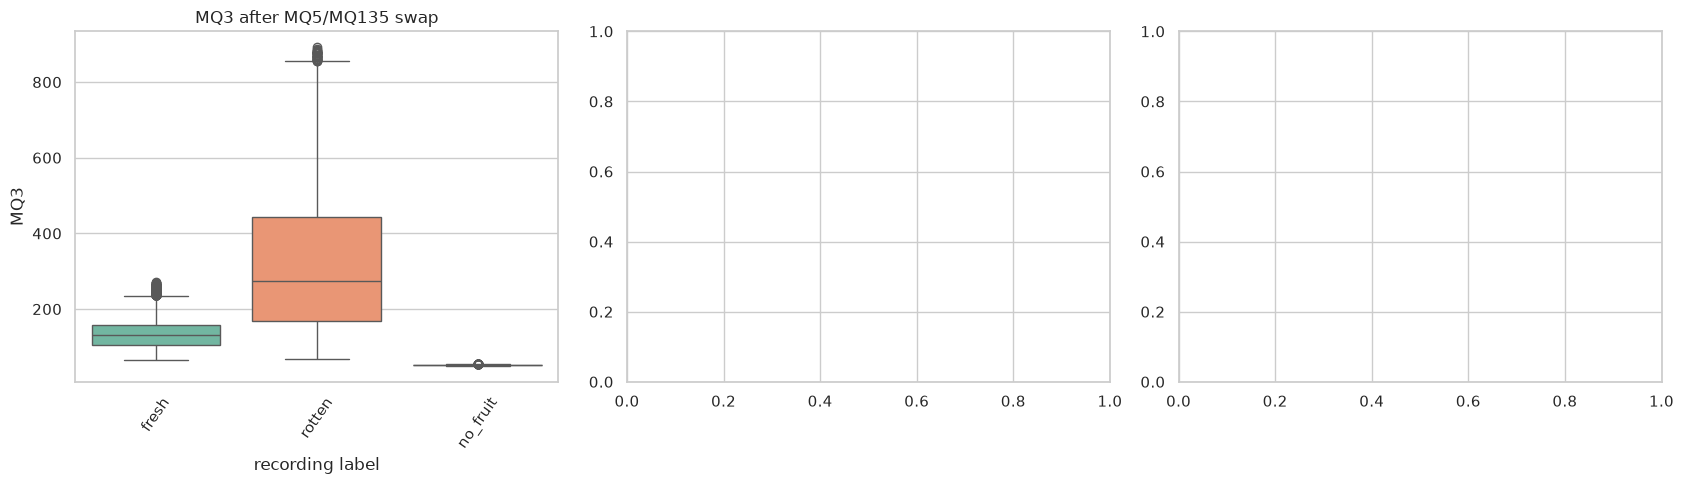

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [4]:
eda_sample = (
    all_data.groupby('source_file', group_keys=False)
       .apply(lambda group: group.iloc[::max(1, len(group) // 500)].head(500))
)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, sensor in zip(axes, BASE_SENSORS):
    sns.boxplot(data=eda_sample, x='freshness', y=sensor, hue='freshness',
                palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{sensor} after MQ5/MQ135 swap')
    ax.tick_params(axis='x', rotation=55)
    ax.set_xlabel('recording label')
    plt.tight_layout()
    plt.show()
plt.show()

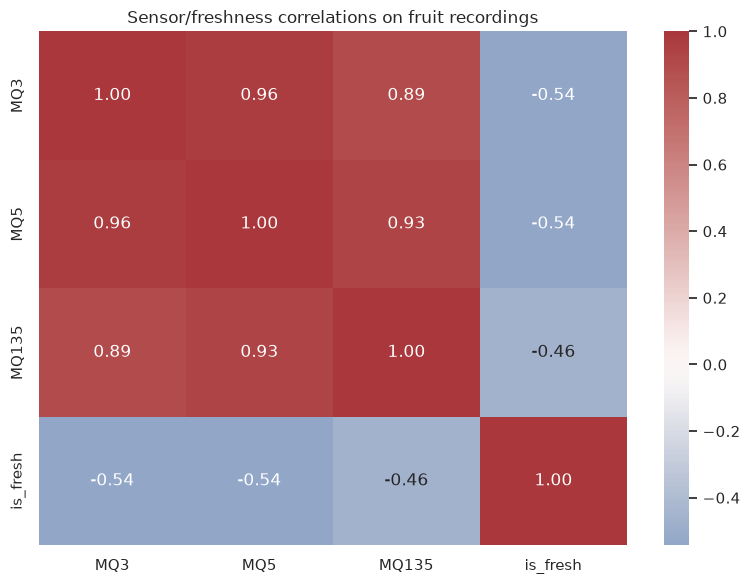

,count,mean,std,min,25%,50%,75%,max
MQ3,1240544.0,240.86,176.97,53.0,128.0,167.0,270.0,941.0
MQ5,1240544.0,974.78,486.09,434.0,680.0,800.0,1097.0,2975.0
MQ135,1240544.0,106.36,131.43,0.0,35.0,67.0,111.0,807.0


In [5]:
fruit_data = all_data[all_data['freshness'].isin(['fresh', 'rotten'])].copy()
corr = fruit_data[BASE_SENSORS + ['is_fresh']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Sensor/freshness correlations on fruit recordings')
plt.tight_layout()
plt.show()

display(fruit_data[BASE_SENSORS].describe().T.round(2))

## 3. Build a leakage-aware SNN dataset

At most 1,500 evenly spaced rows are retained per recording. Complete temporal segments are kept together in the train/test split so adjacent sensor samples do not leak across the boundary.

In [6]:
MAX_ROWS_PER_RECORDING = 1500
sampled = []
for source_file, group in fruit_data.groupby('source_file', sort=True):
    step = max(1, len(group) // MAX_ROWS_PER_RECORDING)
    part = group.iloc[::step].head(MAX_ROWS_PER_RECORDING).copy()
    part['recording'] = source_file
    part['segment'] = np.arange(len(part)) // 100
    sampled.append(part)
snn_data = pd.concat(sampled, ignore_index=True)

# Engineer the same compact gas-sensor features used by the TinyML model.
def make_engineered_features(frame):
    raw = frame[BASE_SENSORS].astype(float)
    features = raw.copy()
    for first, second in [('MQ3', 'MQ5'), ('MQ3', 'MQ135'), ('MQ5', 'MQ135')]:
        features[f'{first}_minus_{second}'] = raw[first] - raw[second]
        features[f'{first}_ratio_{second}'] = raw[first] / (raw[second] + 1e-6)
    features['MQ3_plus_MQ5'] = raw['MQ3'] + raw['MQ5']
    features['MQ3_plus_MQ135'] = raw['MQ3'] + raw['MQ135']
    features['MQ5_plus_MQ135'] = raw['MQ5'] + raw['MQ135']
    features['sensor_mean'] = raw.mean(axis=1)
    features['sensor_std'] = raw.std(axis=1)
    features['sensor_max'] = raw.max(axis=1)
    features['sensor_min'] = raw.min(axis=1)
    features['MQ3_x_MQ5'] = raw['MQ3'] * raw['MQ5']
    features['MQ3_x_MQ135'] = raw['MQ3'] * raw['MQ135']
    features['MQ5_x_MQ135'] = raw['MQ5'] * raw['MQ135']
    return features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

feature_names = make_engineered_features(snn_data).columns.tolist()
X_raw = make_engineered_features(snn_data).to_numpy(dtype=np.float32)
y = snn_data['is_fresh'].to_numpy(dtype=np.float32)
groups = snn_data['recording'] + '_segment_' + snn_data['segment'].astype(str)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(X_raw, y, groups=groups))

scaler = StandardScaler().fit(X_raw[train_idx])
X = np.clip(scaler.transform(X_raw), -3.0, 3.0).astype(np.float32)
print(f'SNN rows: {len(snn_data):,}')
print(f'Engineered features: {len(feature_names)}')
print(f'Train rows: {len(train_idx):,}; test rows: {len(test_idx):,}')
print(f'Train recordings: {snn_data.iloc[train_idx].recording.nunique()}; test recordings: {snn_data.iloc[test_idx].recording.nunique()}')

SNN rows: 24,000
Engineered features: 19
Train rows: 19,200; test rows: 4,800
Train recordings: 16; test recordings: 16


## 4. Train and compare NumPy LIF reservoir SNNs

The hidden layer is a leaky integrate-and-fire reservoir. Engineered sensor features are converted to Bernoulli input spikes over multiple time steps; a trainable ridge readout maps input and hidden spike rates to a freshness score. Several reservoir sizes and leak rates are compared on the same held-out temporal segments. The final score is clipped to `[0, 1]`.

In [7]:
TIME_STEPS = 12


def build_reservoir(input_size, hidden_neurons, seed):
    reservoir_rng = np.random.default_rng(seed)
    input_weights = reservoir_rng.normal(
        0.0, 0.55, size=(input_size, hidden_neurons)
    ).astype(np.float32)
    recurrent_weights = reservoir_rng.normal(
        0.0, 0.12, size=(hidden_neurons, hidden_neurons)
    ).astype(np.float32)
    np.fill_diagonal(recurrent_weights, 0.0)
    return input_weights, recurrent_weights


def lif_features(batch, input_weights, recurrent_weights, decay, threshold, rng):
    hidden_neurons = input_weights.shape[1]
    rates = np.clip(0.5 + 0.14 * batch, 0.05, 0.95).astype(np.float32)
    spikes = rng.random((TIME_STEPS, len(batch), batch.shape[1])) < rates[None, :, :]
    membrane = np.zeros((len(batch), hidden_neurons), dtype=np.float32)
    previous = np.zeros_like(membrane)
    counts = np.zeros_like(membrane)
    for time_index in range(TIME_STEPS):
        current = spikes[time_index].astype(np.float32) @ input_weights
        current += previous @ recurrent_weights
        membrane = decay * membrane + current
        previous = (membrane >= threshold).astype(np.float32)
        membrane = membrane * (1.0 - previous)
        counts += previous
    return np.concatenate([rates, counts / TIME_STEPS], axis=1)


def evaluate_snn_architecture(hidden_neurons, decay, threshold, seed):
    input_weights, recurrent_weights = build_reservoir(
        X.shape[1], hidden_neurons, seed
    )
    train_features = lif_features(
        X[train_idx], input_weights, recurrent_weights, decay, threshold,
        np.random.default_rng(seed)
    )
    test_features = lif_features(
        X[test_idx], input_weights, recurrent_weights, decay, threshold,
        np.random.default_rng(seed + 1)
    )
    model = Ridge(alpha=0.01).fit(train_features, y[train_idx])
    predictions = np.clip(model.predict(test_features), 0.0, 1.0)
    return {
        'hidden_neurons': hidden_neurons,
        'decay': decay,
        'threshold': threshold,
        'mae': mean_absolute_error(y[test_idx], predictions),
        'rmse': mean_squared_error(y[test_idx], predictions) ** 0.5,
        'r2': r2_score(y[test_idx], predictions),
        'input_weights': input_weights,
        'recurrent_weights': recurrent_weights,
        'readout': model,
        'test_features': test_features,
        'predictions': predictions
    }

architecture_configs = [
    (16, 0.80, 1.0),
    (32, 0.80, 1.0),
    (32, 0.85, 1.0),
    (48, 0.85, 1.0),
    (64, 0.90, 1.0),
]
architecture_runs = [
    evaluate_snn_architecture(hidden, decay, threshold, RANDOM_SEED)
    for hidden, decay, threshold in architecture_configs
]
architecture_results = pd.DataFrame([
    {key: run[key] for key in ['hidden_neurons', 'decay', 'threshold', 'mae', 'rmse', 'r2']}
    for run in architecture_runs
]).sort_values('r2', ascending=False).reset_index(drop=True)
display(architecture_results.round(4))

best_row = architecture_results.iloc[0]
best_snn = next(
    run for run in architecture_runs
    if run['hidden_neurons'] == best_row['hidden_neurons']
    and run['decay'] == best_row['decay']
    and run['threshold'] == best_row['threshold']
)
test_scores = best_snn['predictions']
train_scores = np.clip(
    best_snn['readout'].predict(
        lif_features(
            X[train_idx], best_snn['input_weights'], best_snn['recurrent_weights'],
            best_snn['decay'], best_snn['threshold'], np.random.default_rng(RANDOM_SEED)
        )
    ), 0.0, 1.0
)
print(f'Best architecture: {int(best_snn["hidden_neurons"])} hidden neurons, decay={best_snn["decay"]}')
print(f'Score range: [{test_scores.min():.3f}, {test_scores.max():.3f}]')
print(f'Test MAE: {best_snn["mae"]:.4f}')
print(f'Test RMSE: {best_snn["rmse"]:.4f}')
print(f'Test R2: {best_snn["r2"]:.4f}')

,hidden_neurons,decay,threshold,mae,rmse,r2
0,32,0.85,1.0,0.2803,0.3771,0.4150
1,32,0.80,1.0,0.2804,0.3771,0.4149
2,16,0.80,1.0,0.2804,0.3772,0.4146
3,64,0.90,1.0,0.2802,0.3774,0.4140
4,48,0.85,1.0,0.2808,0.3779,0.4125


Best architecture: 32 hidden neurons, decay=0.85
Score range: [0.000, 1.000]
Test MAE: 0.2803
Test RMSE: 0.3771
Test R2: 0.4150


,source_file,freshness,target_freshness,predicted_freshness,predicted_class
400,apple_fresh.csv,fresh,1.0,0.785,fresh
401,apple_fresh.csv,fresh,1.0,0.791,fresh
402,apple_fresh.csv,fresh,1.0,0.796,fresh
403,apple_fresh.csv,fresh,1.0,0.808,fresh
404,apple_fresh.csv,fresh,1.0,0.825,fresh
405,apple_fresh.csv,fresh,1.0,0.782,fresh
406,apple_fresh.csv,fresh,1.0,0.818,fresh
407,apple_fresh.csv,fresh,1.0,0.781,fresh
408,apple_fresh.csv,fresh,1.0,0.797,fresh
409,apple_fresh.csv,fresh,1.0,0.807,fresh


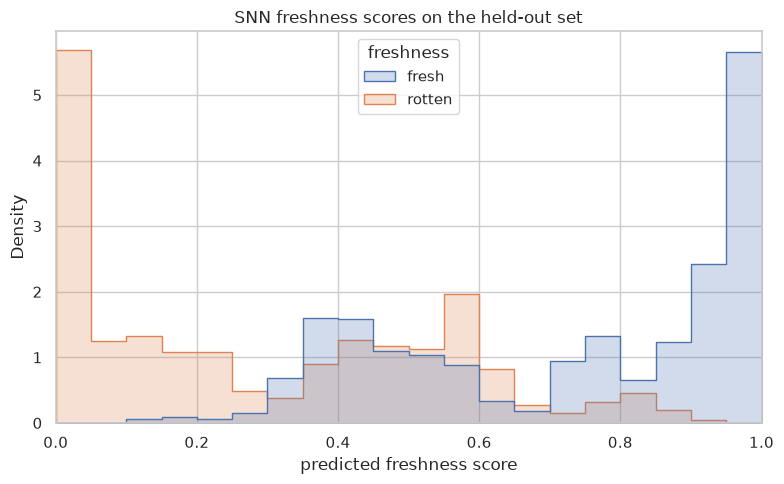

In [8]:
results = snn_data.iloc[test_idx][['source_file', 'freshness']].copy()
results['target_freshness'] = y[test_idx]
results['predicted_freshness'] = test_scores
results['predicted_class'] = np.where(test_scores >= 0.5, 'fresh', 'rotten')
display(results.head(20).round(3))

plt.figure(figsize=(8, 5))
sns.histplot(data=results, x='predicted_freshness', hue='freshness', bins=20,
             stat='density', common_norm=False, element='step')
plt.xlim(0, 1)
plt.title('SNN freshness scores on the held-out set')
plt.xlabel('predicted freshness score')
plt.tight_layout()
plt.show()

## Conclusions

- `no_fruit.csv` is used as a reference recording during EDA and is excluded from supervised training because it has no freshness target.
- All supervised files use only the swapped `MQ3`, `MQ5`, and `MQ135` values.
- The SNN returns a bounded continuous freshness score, while `0.5` is used only as a reporting threshold for fresh versus rotten.
- The temporal-segment split is intentionally stricter than a random row split; independent recordings should be collected for stronger deployment validation.